# DINOv2 Regression — k_min, k_max, sigma

**Vision Transformer backbone (DINOv2 ViT-S/14) with a joint regression head.**

Key design choices vs. ResNet50 joint model:
- **3-channel input**: grayscale image repeated → RGB (required by ViT patch embedding)
- **ImageNet pre-training**: DINOv2 uses self-supervised DINO pre-training on ImageNet-22K
- **112×112 input**: native data is 128×128; downsampled to 112 → 8×8 = 64 patch tokens per image (ViT-S/14)
- **Latent space**: [CLS] token (384-dim) extracted for t-SNE interpretation
- **Full fine-tune from epoch 1**: backbone + head trained jointly with differential LRs (backbone 1e-5, head 1e-3)

In [ ]:
# Cell 1 — Imports & config
from pathlib import Path
import json, time, sys
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import multiprocessing as mp

# ── Paths ──────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / 'src'))

DATA_FILE  = PROJECT_ROOT / 'data' / 'raw' / 'uniform_kmin_128x128_100000.h5'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'comparison' / 'dino_regression'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparams ────────────────────────────────────────────────────────────
SEED          = 42
IMG_SIZE_DINO = 112      # native data is 128×128; 112 = 8×8 patches for ViT/14
EPOCHS        = 50       # full end-to-end training (no frozen warm-up)
BATCH_SIZE    = 16
LR_BACKBONE   = 1e-5    # low LR for pretrained backbone
LR_HEAD       = 1e-3    # higher LR for randomly-initialised head
NUM_WORKERS   = max(1, mp.cpu_count() - 1)

# ── Target normalisation constants (same as joint_regression) ──────────────
KMIN_LO, KMIN_HI   = 1.0,  62.0
KMAX_LO, KMAX_HI   = 5.0,  64.0
LOG_SIG_LO          = float(np.log(0.01))
LOG_SIG_HI          = float(np.log(5.0))

# ── ImageNet normalisation constants ──────────────────────────────────────
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Project : {PROJECT_ROOT}')
print(f'Data    : {DATA_FILE}')
print(f'Output  : {OUTPUT_DIR}')
print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
print(f'Workers : {NUM_WORKERS}')

In [2]:
# Cell 2 — Load labels and compute global percentiles for image normalisation
with h5py.File(DATA_FILE, 'r') as hf:
    n_total    = hf['images'].shape[0]
    kmin_vals  = hf['parameters']['k_min'][:]
    kmax_vals  = hf['parameters']['k_max'][:]
    sigma_vals = hf['parameters']['sigma'][:]

np.random.seed(SEED)
samp_idx = np.sort(np.random.choice(n_total, size=2000, replace=False))
with h5py.File(DATA_FILE, 'r') as hf:
    samp = hf['images'][samp_idx]

IMG_P1  = float(np.percentile(samp, 1))
IMG_P99 = float(np.percentile(samp, 99))
del samp

print(f'N = {n_total:,}')
print(f'Global image percentiles:  p1={IMG_P1:.4f}  p99={IMG_P99:.4f}')
print(f'Log-sigma range:           [{LOG_SIG_LO:.4f}, {LOG_SIG_HI:.4f}]')

N = 100,000
Global image percentiles:  p1=-2.0818  p99=0.9409
Log-sigma range:           [-4.6052, 1.6094]


In [3]:
# Cell 3 — Dataset: 3-channel + ImageNet normalisation + resize to 224×224
import torch.nn.functional as F

class DINOHdf5Dataset(Dataset):
    """
    Preprocessing pipeline:
      1. Load float32 image
      2. p1/p99 clip → [0, 1]
      3. Repeat grayscale → 3 channels (RGB)
      4. Apply ImageNet mean/std normalisation
      5. Bilinear resize to 224×224
    Labels: [k_min_norm, k_max_norm, log_sigma_norm] in [0, 1]
    """
    def __init__(self, h5_path, indices, kmin_vals, kmax_vals, sigma_vals,
                 img_p1, img_p99,
                 imagenet_mean=IMAGENET_MEAN, imagenet_std=IMAGENET_STD,
                 target_size=IMG_SIZE_DINO):
        self.h5_path     = str(h5_path)
        self.indices     = indices
        self.img_p1      = float(img_p1)
        self.img_range   = float(img_p99 - img_p1) + 1e-8
        self.in_mean     = torch.tensor(imagenet_mean).view(3, 1, 1)
        self.in_std      = torch.tensor(imagenet_std).view(3, 1, 1)
        self.target_size = target_size

        kmin_n  = (kmin_vals[indices]  - KMIN_LO) / (KMIN_HI  - KMIN_LO)
        kmax_n  = (kmax_vals[indices]  - KMAX_LO) / (KMAX_HI  - KMAX_LO)
        log_sig = np.log(np.clip(sigma_vals[indices].astype(np.float64), 1e-9, None))
        sig_n   = (log_sig - LOG_SIG_LO) / (LOG_SIG_HI - LOG_SIG_LO)

        self.labels = np.stack([kmin_n, kmax_n, sig_n], axis=1).astype(np.float32)
        self._h5 = None

    def _get_h5(self):
        if self._h5 is None:
            self._h5 = h5py.File(self.h5_path, 'r')
        return self._h5

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img = self._get_h5()['images'][self.indices[idx]].astype(np.float32)
        img = np.clip((img - self.img_p1) / self.img_range, 0.0, 1.0)  # [0,1]
        t   = torch.from_numpy(img).unsqueeze(0).repeat(3, 1, 1)       # (3, H, W)
        t   = (t - self.in_mean) / self.in_std                          # ImageNet norm
        t   = F.interpolate(t.unsqueeze(0), size=(self.target_size, self.target_size),
                            mode='bilinear', align_corners=False).squeeze(0)  # (3,224,224)
        return t, torch.from_numpy(self.labels[idx])

    def __del__(self):
        if self._h5 is not None:
            self._h5.close()


# Build splits
indices = np.arange(n_total)
train_idx, tmp      = train_test_split(indices, test_size=0.2,  random_state=SEED)
val_idx,   test_idx = train_test_split(tmp,     test_size=0.5,  random_state=SEED)

ds_kwargs = dict(kmin_vals=kmin_vals, kmax_vals=kmax_vals, sigma_vals=sigma_vals,
                 img_p1=IMG_P1, img_p99=IMG_P99)
train_ds = DINOHdf5Dataset(DATA_FILE, train_idx, **ds_kwargs)
val_ds   = DINOHdf5Dataset(DATA_FILE, val_idx,   **ds_kwargs)
test_ds  = DINOHdf5Dataset(DATA_FILE, test_idx,  **ds_kwargs)

loader_kw    = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
train_loader = DataLoader(train_ds, shuffle=True,  **loader_kw)
val_loader   = DataLoader(val_ds,   shuffle=False, **loader_kw)
test_loader  = DataLoader(test_ds,  shuffle=False, **loader_kw)

# Quick sanity check
x_sample, y_sample = train_ds[0]
print(f'Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}')
print(f'Sample image shape : {x_sample.shape}  dtype={x_sample.dtype}')
print(f'Sample label shape : {y_sample.shape}  values={y_sample.numpy().round(4)}')
print(f'Pixel value range  : [{x_sample.min():.3f}, {x_sample.max():.3f}]')

Train: 80,000  Val: 10,000  Test: 10,000
Sample image shape : torch.Size([3, 112, 112])  dtype=torch.float32
Sample label shape : torch.Size([3])  values=[0.918  0.9492 0.9146]
Pixel value range  : [-1.760, 2.345]


In [4]:
# Cell 4 — DINOv2 ViT-S/14 backbone + joint regression head
#
# ViT-S/14 (~21M params, embed_dim=384) chosen over ViT-B/14 to fit smaller GPUs.
# Downloads ~85 MB on first run from torch.hub (facebookresearch/dinov2).

DINO_MODEL = 'dinov2_vits14'   # ViT-S/14: embed_dim=384
EMBED_DIM  = 384

class DINOv2Regressor(nn.Module):
    """
    DINOv2 backbone with a 3-output Sigmoid regression head.
    The backbone can be frozen or fine-tuned via set_backbone_trainable().
    """
    def __init__(self, model_name=DINO_MODEL, embed_dim=EMBED_DIM, n_outputs=3):
        super().__init__()
        self.backbone = torch.hub.load(
            'facebookresearch/dinov2', model_name, pretrained=True, verbose=False)
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 64),        nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, n_outputs),
            nn.Sigmoid()
        )

    def set_backbone_trainable(self, trainable: bool):
        for p in self.backbone.parameters():
            p.requires_grad = trainable

    def forward(self, x):
        feats = self.backbone(x)   # [CLS] token: (B, embed_dim)
        return self.head(feats)    # (B, 3)

    @torch.no_grad()
    def extract_features(self, x):
        """Return raw [CLS] embeddings for latent space analysis."""
        return self.backbone(x)    # (B, embed_dim)


model = DINOv2Regressor().to(DEVICE)
n_backbone = sum(p.numel() for p in model.backbone.parameters())
n_head     = sum(p.numel() for p in model.head.parameters())
print(f'DINOv2 backbone params : {n_backbone:,}')
print(f'Regression head params : {n_head:,}')
print(f'Total params           : {n_backbone + n_head:,}')

/home/davas/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/davas/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/davas/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /home/davas/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:08<00:00, 10.5MB/s]


DINOv2 backbone params : 22,056,576
Regression head params : 115,203
Total params           : 22,171,779


In [5]:
# Cell 5 — Loss, training helpers, denorm

class JointRMSELoss(nn.Module):
    """Sum of per-output RMSE on normalised [0,1] targets (equal weight)."""
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, pred, target):
        mse = (pred - target).pow(2).mean(dim=0)          # (3,)
        return torch.sqrt(mse + self.eps).sum()            # scalar


def train_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total = 0.0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        if scaler:
            with torch.amp.autocast('cuda'):
                loss = criterion(model(X), y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
        total += loss.item() * len(X)
    return total / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total, preds, targets = 0.0, [], []
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        pred  = model(X)
        total += criterion(pred, y).item() * len(X)
        preds.append(pred.cpu())
        targets.append(y.cpu())
    preds   = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()
    mae_per = np.mean(np.abs(preds - targets), axis=0)
    return total / len(loader.dataset), mae_per, preds, targets


def denorm(preds_norm, targets_norm):
    """Convert normalised [0,1] predictions back to physical parameter scales."""
    p_kmin = preds_norm[:, 0]  * (KMIN_HI - KMIN_LO)  + KMIN_LO
    p_kmax = preds_norm[:, 1]  * (KMAX_HI - KMAX_LO)  + KMAX_LO
    p_sig  = np.exp(preds_norm[:, 2]  * (LOG_SIG_HI - LOG_SIG_LO) + LOG_SIG_LO)
    t_kmin = targets_norm[:, 0] * (KMIN_HI - KMIN_LO)  + KMIN_LO
    t_kmax = targets_norm[:, 1] * (KMAX_HI - KMAX_LO)  + KMAX_LO
    t_sig  = np.exp(targets_norm[:, 2] * (LOG_SIG_HI - LOG_SIG_LO) + LOG_SIG_LO)
    return ({'k_min': p_kmin, 'k_max': p_kmax, 'sigma': p_sig},
            {'k_min': t_kmin, 'k_max': t_kmax, 'sigma': t_sig})


print('Loss, helpers, and denorm defined.')

Loss, helpers, and denorm defined.


In [ ]:
# Cell 6 — Smoke test (500 train / 200 val, 5 epochs, full model unfrozen)
rng = np.random.RandomState(SEED)
smoke_train = DataLoader(Subset(train_ds, rng.choice(len(train_ds), 500, replace=False)),
                         batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
smoke_val   = DataLoader(Subset(val_ds,   rng.choice(len(val_ds),   200, replace=False)),
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

sm   = DINOv2Regressor().to(DEVICE)
sm.set_backbone_trainable(True)   # full model from the start
crit = JointRMSELoss().to(DEVICE)
opt  = optim.AdamW([
    {'params': sm.backbone.parameters(), 'lr': LR_BACKBONE, 'weight_decay': 1e-4},
    {'params': sm.head.parameters(),     'lr': LR_HEAD,     'weight_decay': 1e-4},
])
sc   = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None

for ep in range(5):
    tl = train_epoch(sm, smoke_train, crit, opt, sc, DEVICE)
    vl, vm, _, _ = eval_epoch(sm, smoke_val, crit, DEVICE)
    print(f'Smoke ep {ep+1}/5 | train {tl:.4f} | val {vl:.4f} | kmin={vm[0]:.3f} kmax={vm[1]:.3f} sig={vm[2]:.3f}')

del sm, opt, sc
print('Smoke test passed.')

In [ ]:
# Cell 7 — Full training: end-to-end fine-tune (resume-safe)
results_path = OUTPUT_DIR / 'results.json'
best_ckpt    = OUTPUT_DIR / 'best_model.pt'

if results_path.exists():
    print(f'[SKIP] results.json exists — jump to Cell 8 to load results')
else:
    model     = DINOv2Regressor().to(DEVICE)
    model.set_backbone_trainable(True)
    criterion = JointRMSELoss().to(DEVICE)
    scaler    = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None

    optimizer = optim.AdamW([
        {'params': model.backbone.parameters(), 'lr': LR_BACKBONE, 'weight_decay': 1e-4},
        {'params': model.head.parameters(),     'lr': LR_HEAD,     'weight_decay': 1e-4},
    ])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-7)

    history = {'train_loss': [], 'val_loss': [],
               'val_mae_kmin': [], 'val_mae_kmax': [], 'val_mae_sigma': []}
    best_val  = float('inf')
    run_start = time.time()

    print(f'Full fine-tune: {EPOCHS} epochs  |  backbone LR={LR_BACKBONE}  head LR={LR_HEAD}')
    for epoch in range(EPOCHS):
        tl           = train_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE)
        vl, vm, _, _ = eval_epoch(model, val_loader,   criterion, DEVICE)
        scheduler.step()
        for key, val in [('train_loss', tl), ('val_loss', vl),
                         ('val_mae_kmin', vm[0]), ('val_mae_kmax', vm[1]),
                         ('val_mae_sigma', vm[2])]:
            history[key].append(float(val))
        lr_bb = optimizer.param_groups[0]['lr']
        if torch.cuda.is_available():
            temp = torch.cuda.temperature() if hasattr(torch.cuda, 'temperature') else '?'
            mem  = torch.cuda.memory_reserved() / 1e9
        else:
            temp, mem = '?', 0.0
        print(f'  Ep {epoch+1:2d}/{EPOCHS} | train {tl:.4f} | val {vl:.4f}'
              f' | kmin={vm[0]:.4f} kmax={vm[1]:.4f} sig={vm[2]:.4f}'
              f' | lr {lr_bb:.1e} | VRAM {mem:.1f}GB')
        if vl < best_val:
            best_val = vl
            torch.save(model.state_dict(), best_ckpt)
        # give the GPU a moment to cool between epochs
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        time.sleep(2)

    training_time = (time.time() - run_start) / 60
    print(f'\nTraining done in {training_time:.1f} min  |  best val: {best_val:.4f}')

    # Evaluate on test set
    model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
    _, _, y_pred_n, y_true_n = eval_epoch(model, test_loader, criterion, DEVICE)
    y_pred_d, y_true_d = denorm(y_pred_n, y_true_n)
    params = ['k_min', 'k_max', 'sigma']
    metrics = {
        p: {'mae':  float(mean_absolute_error(y_true_d[p], y_pred_d[p])),
            'rmse': float(np.sqrt(mean_squared_error(y_true_d[p], y_pred_d[p]))),
            'r2':   float(r2_score(y_true_d[p], y_pred_d[p]))}
        for p in params
    }

    results = {'history': history, 'metrics': metrics,
               'y_true': {p: y_true_d[p].tolist() for p in params},
               'y_pred': {p: y_pred_d[p].tolist() for p in params},
               'training_time_min': training_time,
               'best_val_loss': best_val}
    with open(results_path, 'w') as f:
        json.dump(results, f)
    print(f'Results saved → {results_path}')

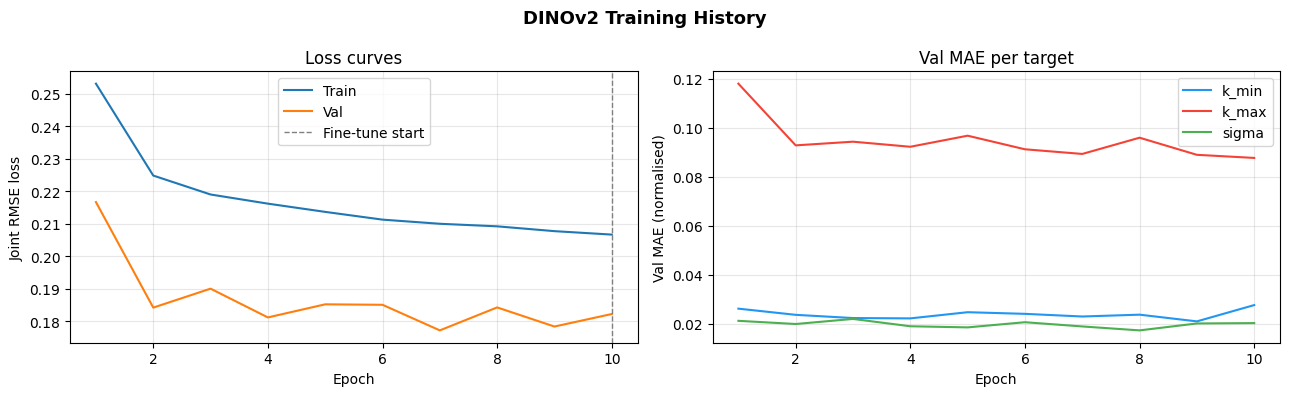

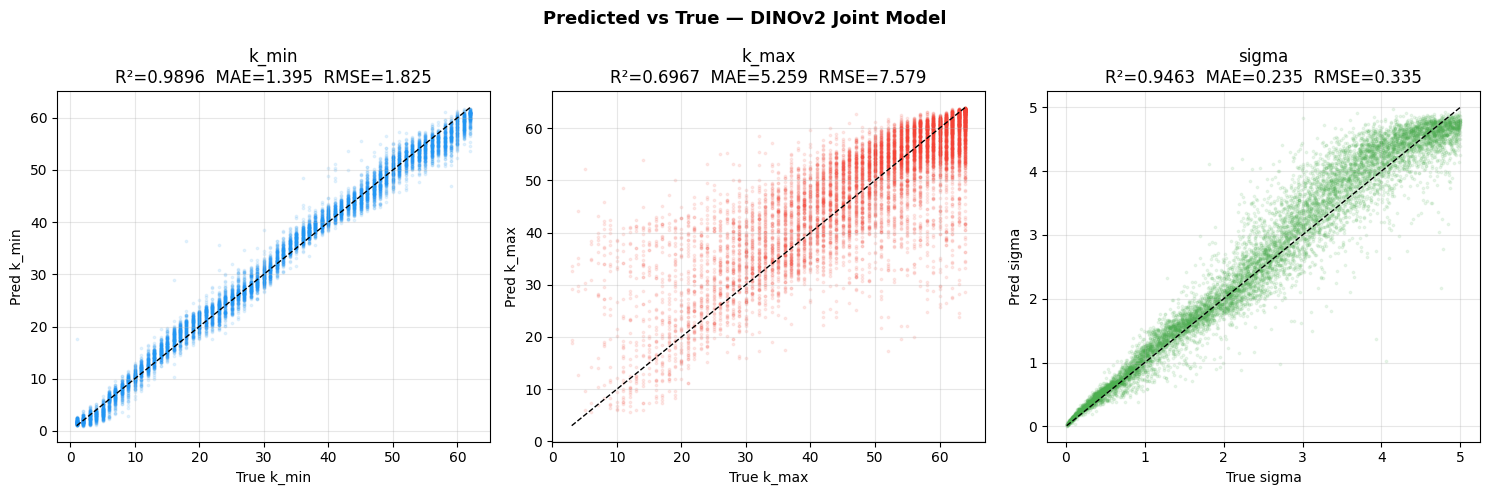


DINOv2 Joint — test set performance
PARAM         MAE     RMSE       R²
----------------------------------------------------
k_min       1.395    1.825   0.9896  (2.3%)
k_max       5.259    7.579   0.6967  (8.9%)
sigma       0.235    0.335   0.9463  (4.7%)


In [8]:
# Cell 8 — Load results and evaluation plots
if 'results' not in globals():
    with open(results_path, 'r') as f:
        results = json.load(f)
    print(f'Loaded results from {results_path}')

params = ['k_min', 'k_max', 'sigma']
colors = {'k_min': '#2196F3', 'k_max': '#F44336', 'sigma': '#4CAF50'}

# ── Training curves ────────────────────────────────────────────────────────
h = results['history']
ep_range = range(1, len(h['train_loss']) + 1)
phases   = h.get('phase', [])
switch   = sum(1 for p in phases if p == 'frozen')   # epoch where fine-tuning starts

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ep_range, h['train_loss'], label='Train')
axes[0].plot(ep_range, h['val_loss'],   label='Val')
if switch:
    axes[0].axvline(switch, color='gray', linestyle='--', linewidth=1, label='Fine-tune start')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Joint RMSE loss')
axes[0].set_title('Loss curves'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

for p, key in [('k_min','val_mae_kmin'),('k_max','val_mae_kmax'),('sigma','val_mae_sigma')]:
    if key in h:
        axes[1].plot(ep_range, h[key], label=p, color=colors[p])
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val MAE (normalised)')
axes[1].set_title('Val MAE per target'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('DINOv2 Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Scatter plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, param in zip(axes, params):
    yt = np.array(results['y_true'][param])
    yp = np.array(results['y_pred'][param])
    m  = results['metrics'][param]
    ax.scatter(yt, yp, alpha=0.10, s=3, color=colors[param], rasterized=True)
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, 'k--', linewidth=1)
    ax.set_xlabel(f'True {param}'); ax.set_ylabel(f'Pred {param}')
    ax.set_title(f'{param}\nR²={m["r2"]:.4f}  MAE={m["mae"]:.3f}  RMSE={m["rmse"]:.3f}')
    ax.grid(True, alpha=0.3)
plt.suptitle('Predicted vs True — DINOv2 Joint Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
ranges = {'k_min': KMIN_HI-KMIN_LO, 'k_max': KMAX_HI-KMAX_LO,
          'sigma': np.exp(LOG_SIG_HI)-np.exp(LOG_SIG_LO)}
print(f"\n{'='*52}")
print(f"DINOv2 Joint — test set performance")
print(f"{'='*52}")
print(f"{'PARAM':<8} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print(f"{'-'*52}")
for p, m in results['metrics'].items():
    pct = 100 * m['mae'] / ranges[p]
    print(f"{p:<8} {m['mae']:>8.3f} {m['rmse']:>8.3f} {m['r2']:>8.4f}  ({pct:.1f}%)")
print(f"{'='*52}")

Embeddings shape: (3000, 384)
Running t-SNE... (may take 1-2 min)
t-SNE done. KL divergence: 1.0483


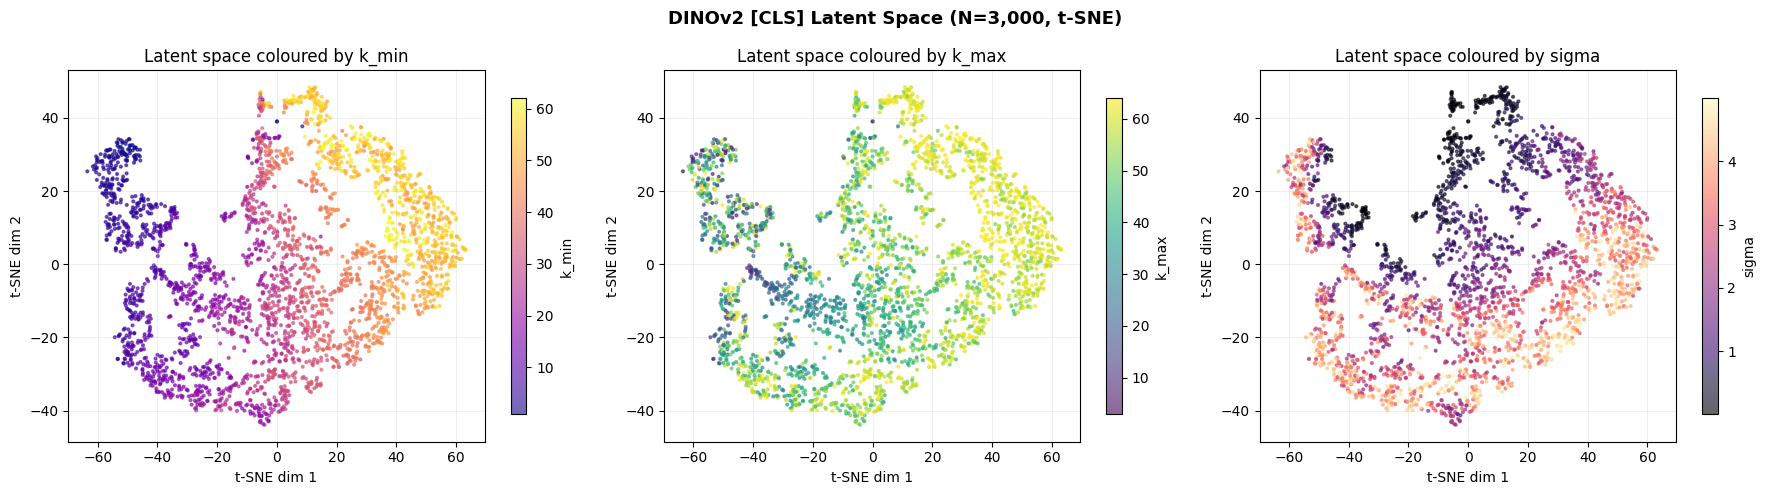

In [10]:
# Cell 9 — Latent space: extract [CLS] embeddings + t-SNE visualisation
#
# Uses a random 3000-image subset of the test set for tractable t-SNE computation.
# Each point is coloured by its true k_min / k_max / sigma value.

N_LATENT = 3000

# Load best model
if 'model' not in globals():
    model = DINOv2Regressor().to(DEVICE)
if best_ckpt.exists():
    model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
model.eval()

# Sample indices from test set
rng      = np.random.RandomState(SEED)
lat_idx  = rng.choice(len(test_ds), min(N_LATENT, len(test_ds)), replace=False)
lat_ds   = Subset(test_ds, lat_idx)
lat_ldr  = DataLoader(lat_ds, batch_size=64, shuffle=False, num_workers=0)

embeddings, labels_all = [], []
with torch.no_grad():
    for X, y in lat_ldr:
        emb = model.extract_features(X.to(DEVICE)).cpu().numpy()  # (B, 768)
        embeddings.append(emb)
        labels_all.append(y.numpy())

embeddings = np.concatenate(embeddings, axis=0)   # (N, 768)
labels_all = np.concatenate(labels_all, axis=0)   # (N, 3)
print(f'Embeddings shape: {embeddings.shape}')

# Denorm labels for colour scale
lab_kmin  = labels_all[:, 0] * (KMIN_HI - KMIN_LO) + KMIN_LO
lab_kmax  = labels_all[:, 1] * (KMAX_HI - KMAX_LO) + KMAX_LO
lab_sigma = np.exp(labels_all[:, 2] * (LOG_SIG_HI - LOG_SIG_LO) + LOG_SIG_LO)

# t-SNE (perplexity=30 works well for ~3K points)
print('Running t-SNE... (may take 1-2 min)')
tsne  = TSNE(n_components=2, perplexity=30, learning_rate='auto',
             init='pca', random_state=SEED, max_iter=1000)
proj  = tsne.fit_transform(embeddings)   # (N, 2)
print(f't-SNE done. KL divergence: {tsne.kl_divergence_:.4f}')

# Plot: one panel per parameter
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
param_data = [
    ('k_min',  lab_kmin,  'plasma'),
    ('k_max',  lab_kmax,  'viridis'),
    ('sigma',  lab_sigma, 'magma'),
]
for ax, (label, vals, cmap) in zip(axes, param_data):
    sc = ax.scatter(proj[:, 0], proj[:, 1], c=vals, cmap=cmap, s=4, alpha=0.6, rasterized=True)
    plt.colorbar(sc, ax=ax, label=label, shrink=0.85)
    ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')
    ax.set_title(f'Latent space coloured by {label}')
    ax.grid(True, alpha=0.2)

plt.suptitle(f'DINOv2 [CLS] Latent Space (N={len(proj):,}, t-SNE)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'latent_tsne.png', dpi=150, bbox_inches='tight')
plt.show()